## Pitch Classification in Baseball

### *Goals*:
- Build a Pitch Classification model that takes pitch-level characteristics and predicts the pitch type label.
- Evaluate and compare the performance of different classification algorithms on the pitch data.
- Interpret model outputs and discuss the findings

In [15]:
# Install Some Dependancies
!pip install pybaseball --quiet
!pip install xgboost --quiet
%config InlineBackend.figure_format = 'retina'

In [2]:
from pybaseball import statcast

In [3]:
# Utilize pitching data from August 2025
data = statcast(start_dt="2025-08-01", end_dt="2025-08-30")

This is a large query, it may take a moment to complete


  0%|          | 0/30 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = d

In [4]:
%config InlineBackend.figure_format = 'retina'

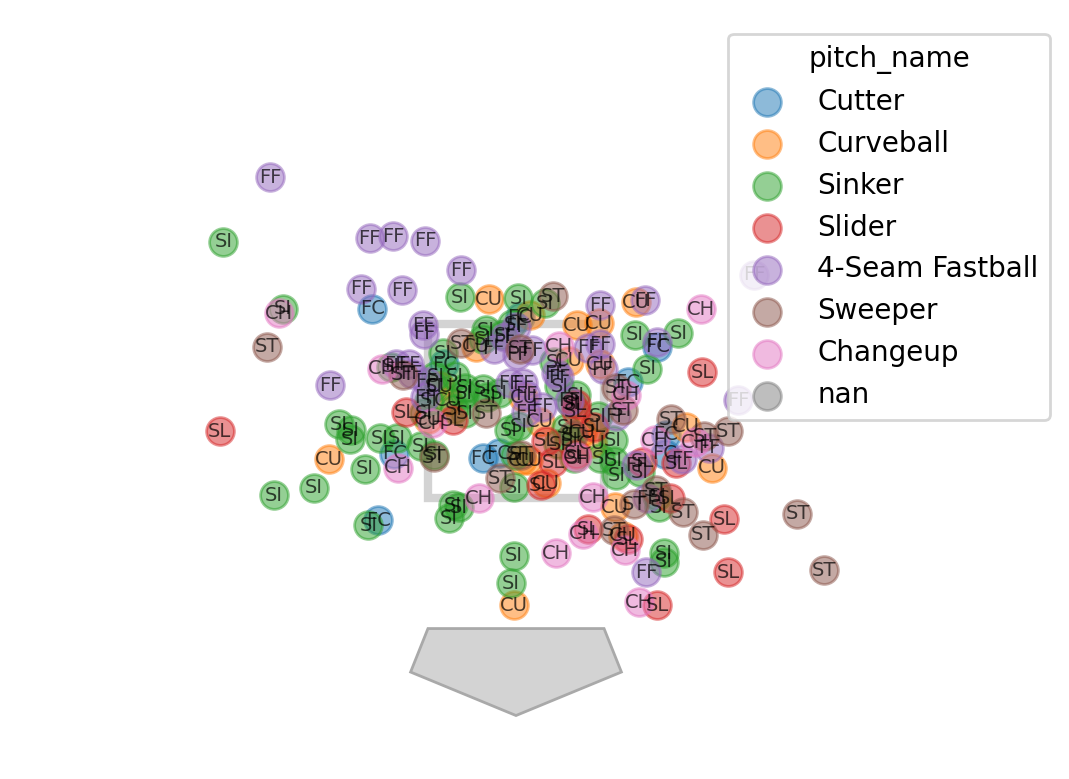

In [5]:
from pybaseball.plotting import plot_strike_zone
ax = plot_strike_zone(data.iloc[:200], colorby="pitch_name")

**Goal #1: Build a Pitch Classification model that takes pitch-level characteristics and predicts the pitch type label.**

In [6]:
#STEP 1: Import libraries we need

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np

In [7]:
#STEP 2: Import pitching data
start_dt="2025-08-01"
end_dt="2025-08-30"
data = statcast(start_dt, end_dt)
print("Rows, columns:", data.shape)
print("Useful columns available:", [c for c in data.columns if c in [
    'release_speed','release_spin_rate','pfx_x','pfx_z','release_pos_x','release_pos_z','pitch_type']])

This is a large query, it may take a moment to complete


  0%|          | 0/30 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = d

Rows, columns: (119904, 118)
Useful columns available: ['pitch_type', 'release_speed', 'release_pos_x', 'release_pos_z', 'pfx_x', 'pfx_z', 'release_spin_rate']


In [8]:
#STEP 3: Import all necessary libraries

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [10]:
#STEP 4: Clean data and create a stratified train/test split

# Drop rows where the target (pitch_type) is missing
target = 'pitch_type'
features = ['release_speed','release_spin_rate','pfx_x','pfx_z','release_pos_x','release_pos_z']

data = data.dropna(subset=[target]).copy()

# Identify classes with only one member and remove them for stratified splitting
pitch_type_counts = data[target].value_counts()
single_instance_pitch_types = pitch_type_counts[pitch_type_counts == 1].index
data = data[~data[target].isin(single_instance_pitch_types)]

# Now re-create X and y
X = data[features]
y = data[target]

# Split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
#STEP 5: Define models (k-NN, Random Forest, XGBoost) to be evaluated

models = {
    "k-NN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="mlogloss")
}


k-NN Metrics:
  Accuracy : 0.926
  Precision: 0.795
  Recall   : 0.759
  F1-Score : 0.775



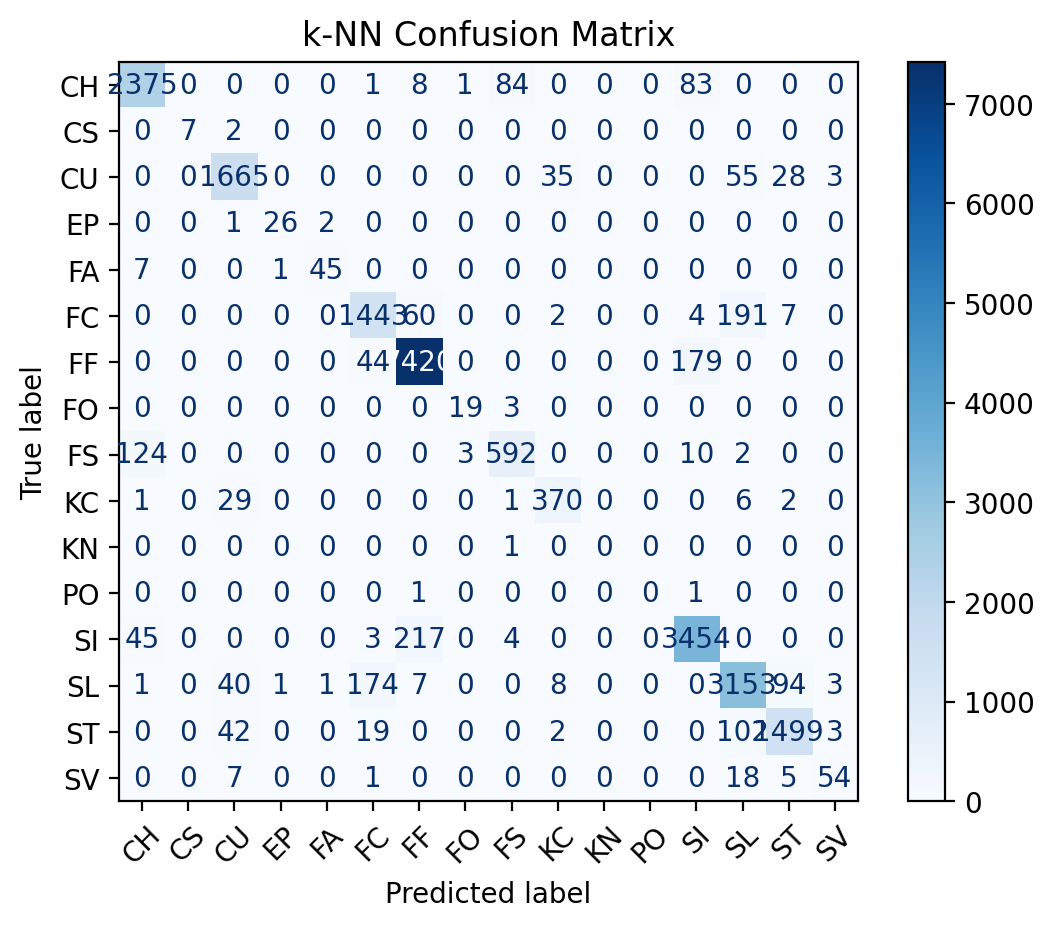

Random Forest Metrics:
  Accuracy : 0.911
  Precision: 0.861
  Recall   : 0.755
  F1-Score : 0.792



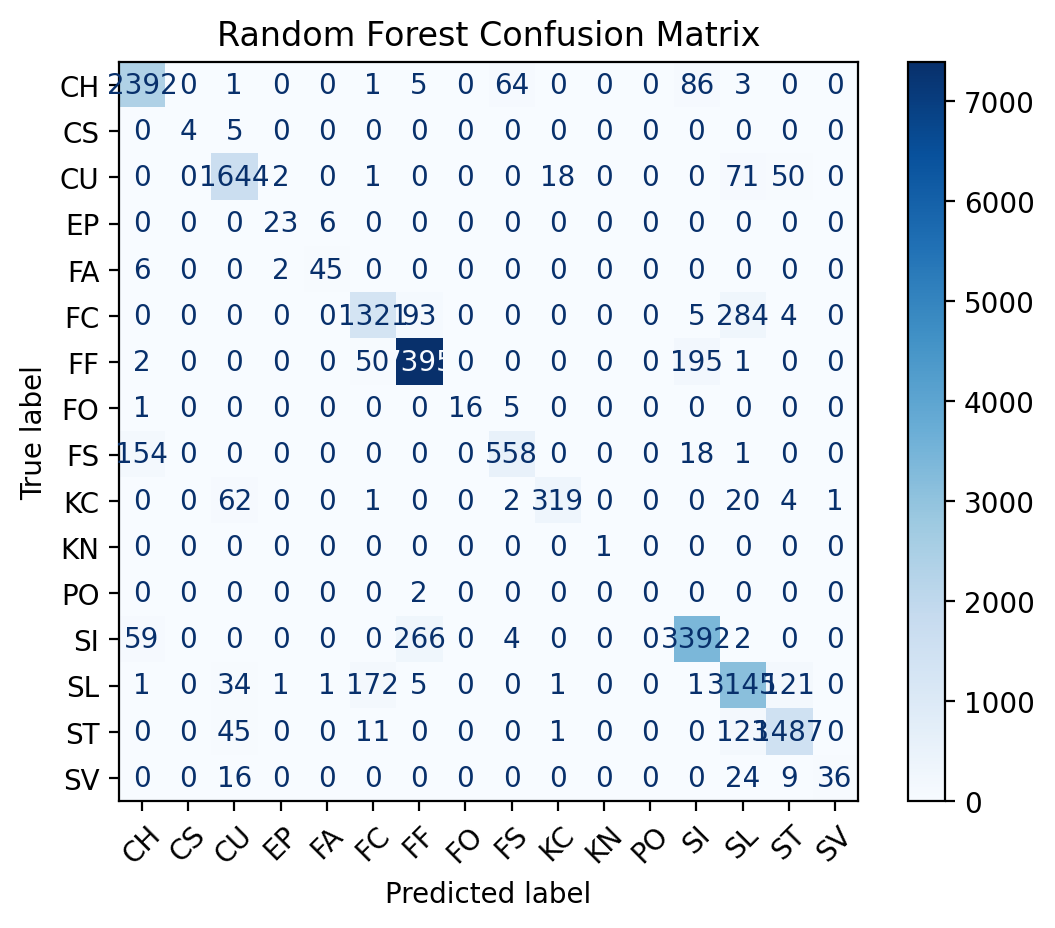

XGBoost Metrics:
  Accuracy : 0.906
  Precision: 0.844
  Recall   : 0.785
  F1-Score : 0.810



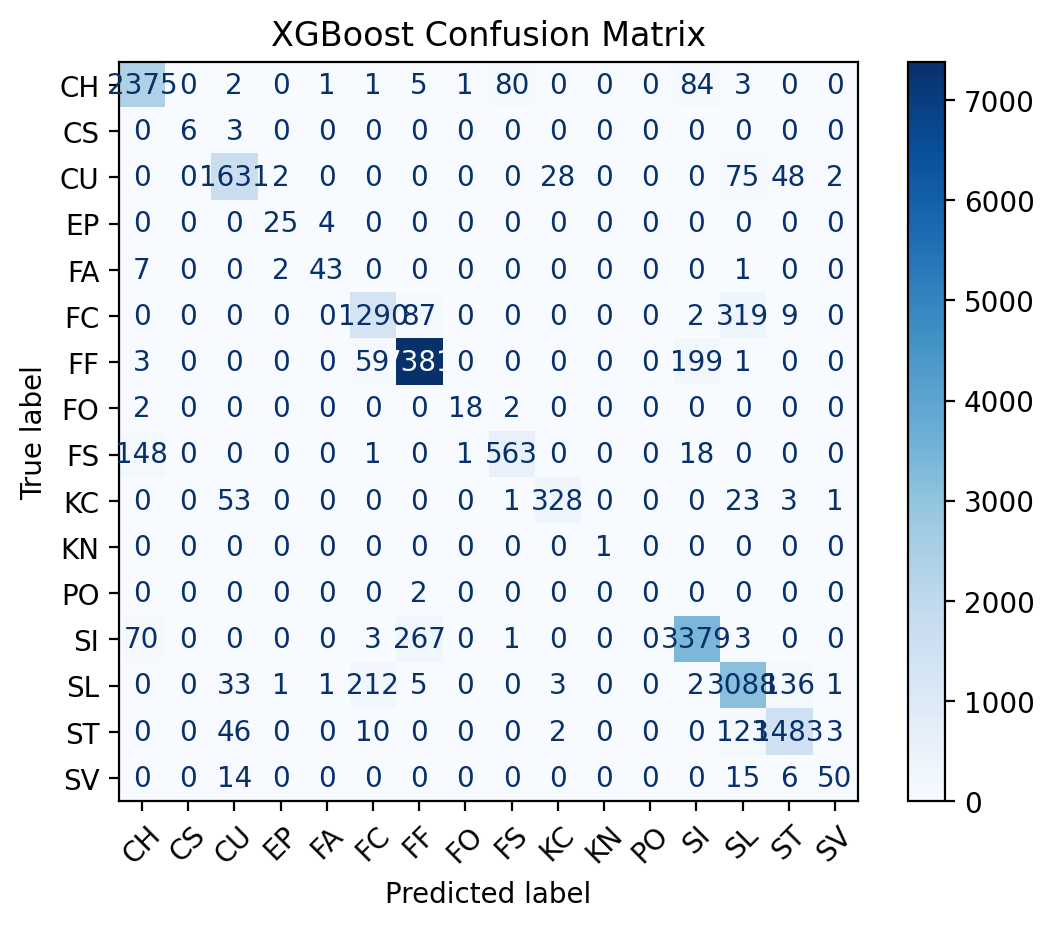

In [12]:
#STEP 6: Evaluate performance metrics and display confusion matrices

# Encode target variable (works for ALL models)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('clf', model)
    ])

    # Train on encoded targets
    pipeline.fit(X_train, y_train_encoded)
    y_pred = pipeline.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test_encoded, y_pred)
    precision = precision_score(y_test_encoded, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test_encoded, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test_encoded, y_pred, average='macro', zero_division=0)

    results.append([name, acc, precision, recall, f1])

    # Print metrics
    print(f"{name} Metrics:")
    print(f"  Accuracy : {acc:.3f}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall   : {recall:.3f}")
    print(f"  F1-Score : {f1:.3f}\n")

    # Confusion matrix
    cm = confusion_matrix(y_test_encoded, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title(f"{name} Confusion Matrix")
    plt.show()


**Goal #2: Evaluate and compare the performance of different classification algorithms on the pitch data.**


Model Comparison Table:
        Model  Accuracy  Precision  Recall  F1-Score
         k-NN     0.926      0.795   0.759     0.775
Random Forest     0.911      0.861   0.755     0.792
      XGBoost     0.906      0.844   0.785     0.810


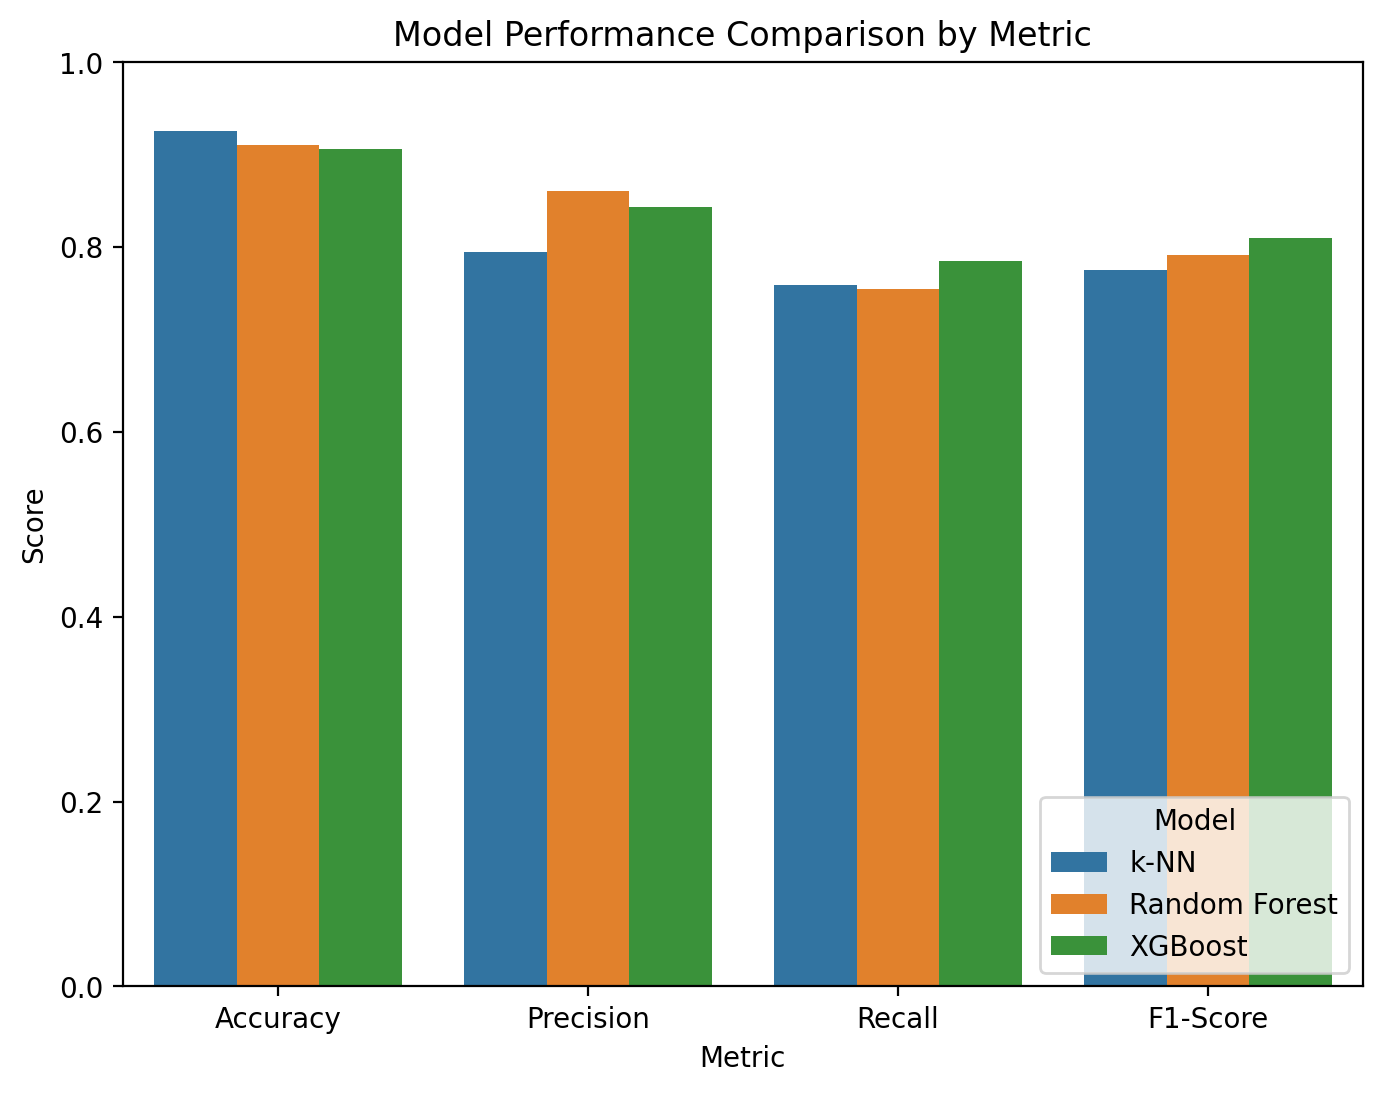

In [13]:
#Compare models based on accuracy, precision, recall and F1-Score

# Build DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']).copy()
results_df = results_df.round(3)

print("\nModel Comparison Table:")
print(results_df.to_string(index=False))

# Melt dataframe so we can group by metrics instead of models
melted_df = results_df.melt(id_vars="Model",
                            value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
                            var_name="Metric",
                            value_name="Score")

# Bar plot grouped by metric
plt.figure(figsize=(8,6))
import seaborn as sns
sns.barplot(data=melted_df, x="Metric", y="Score", hue="Model")

plt.title("Model Performance Comparison by Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model", loc="lower right")
plt.show()


**Goal 3: Interpret model outputs and discuss the findings**

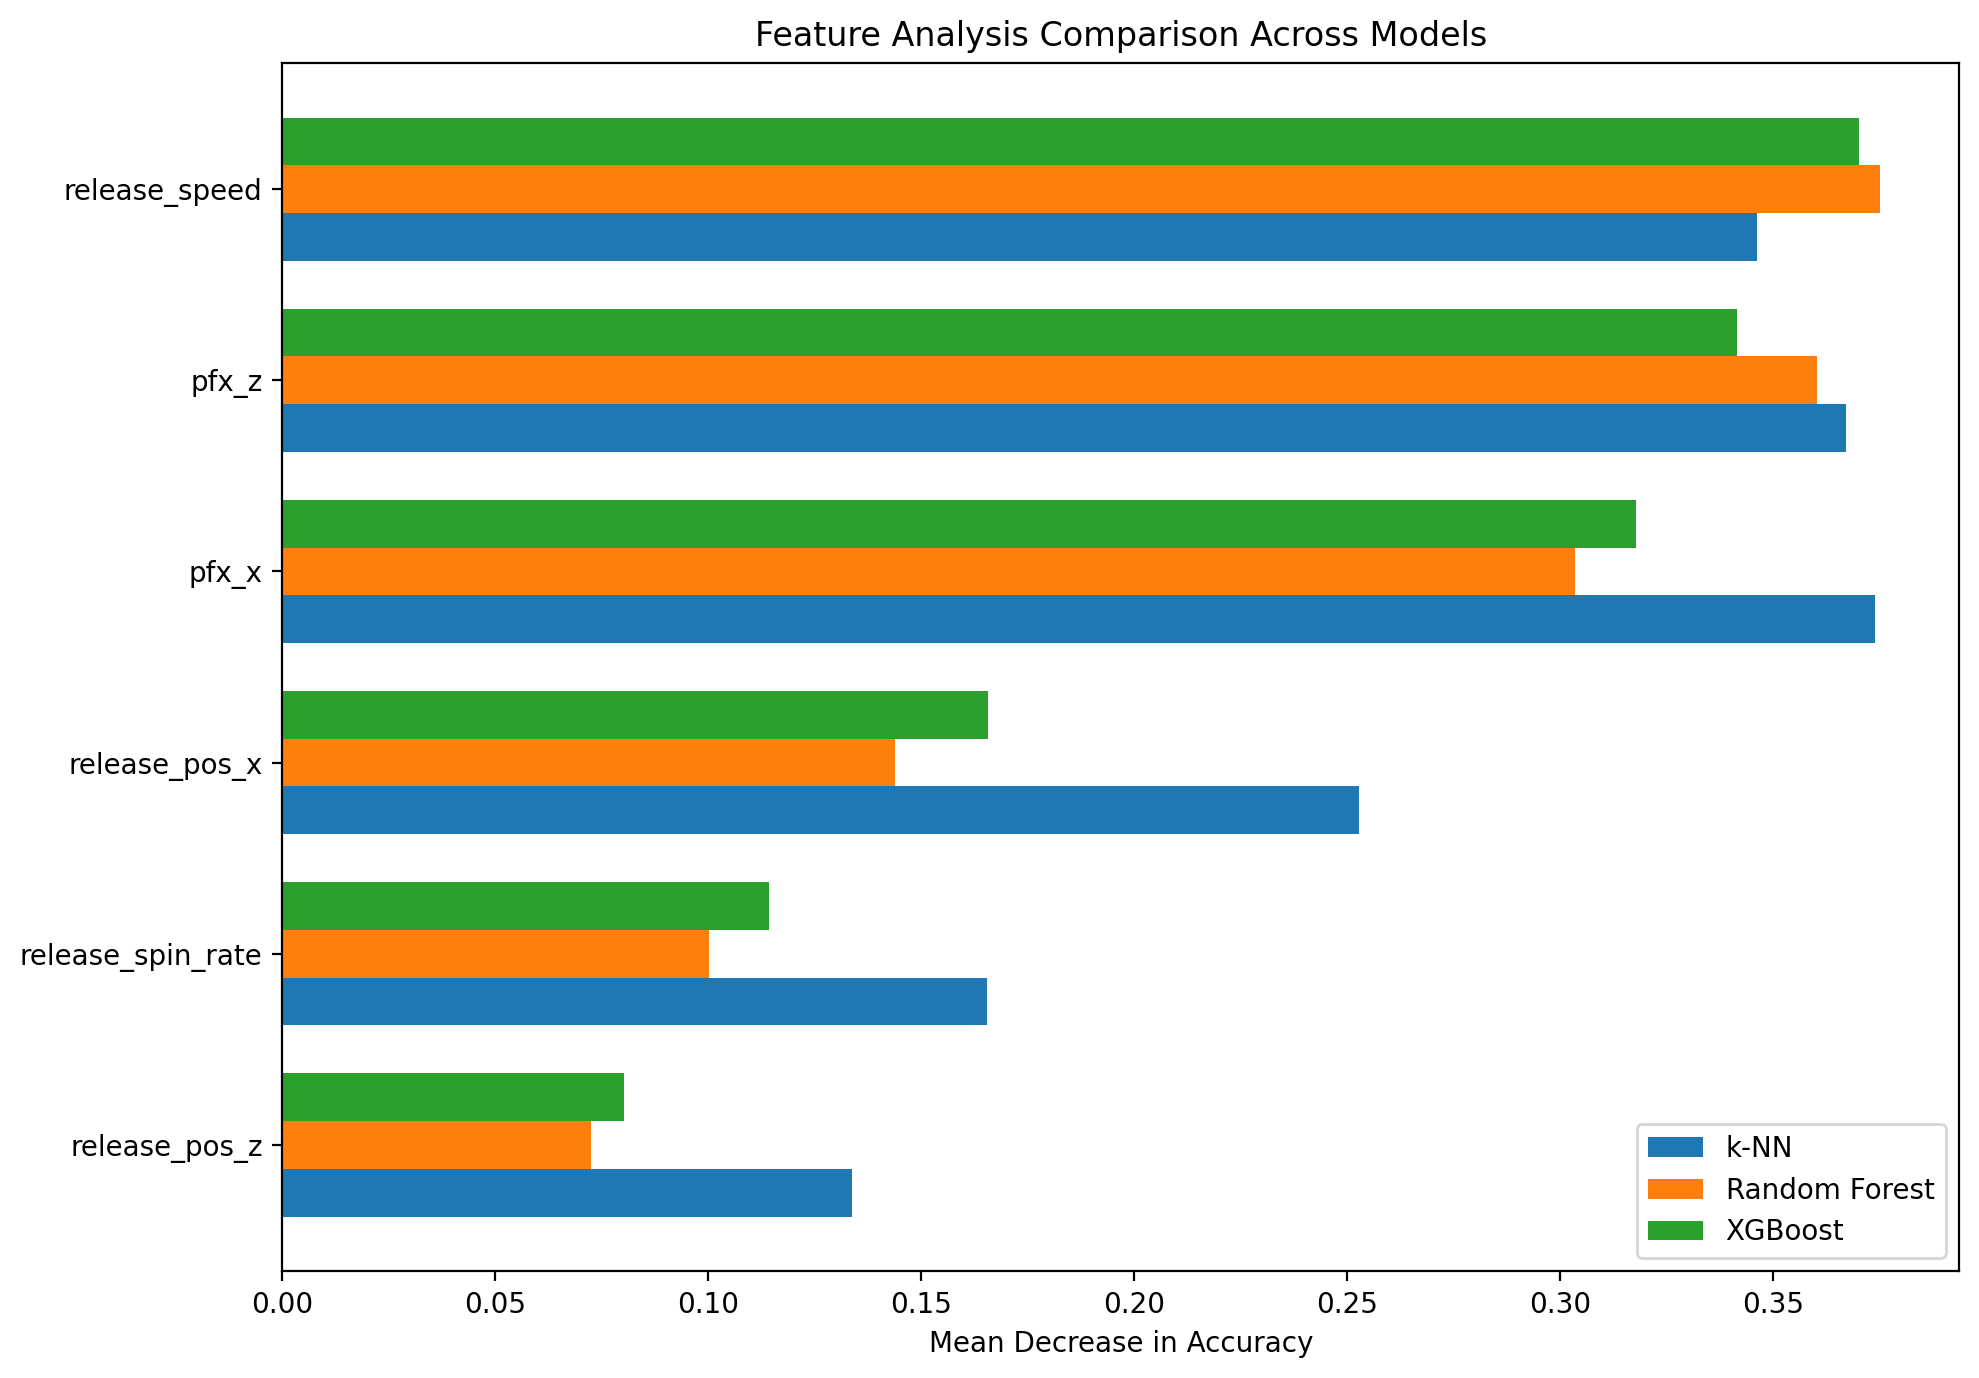

In [14]:
#Determine features of most importance across models

# Store results for all models
all_importances = pd.DataFrame(index=X_train.columns)

for name, model in models.items():
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('clf', model)
    ])

    pipeline.fit(X_train, y_train_encoded)

    result = permutation_importance(
        pipeline, X_test, y_test_encoded, n_repeats=10, random_state=42, n_jobs=-1
    )

    all_importances[name] = result.importances_mean

# Sort features by the mean importance across all models
all_importances['mean'] = all_importances.mean(axis=1)
all_importances = all_importances.sort_values('mean')
all_importances.drop(columns='mean', inplace=True)

# Define the order of models
model_order = ['k-NN', 'Random Forest', 'XGBoost']
all_importances = all_importances[model_order]

# Plot side-by-side bars
features = all_importances.index
x = np.arange(len(features))
width = 0.25

plt.figure(figsize=(10,7))
plt.barh(x - width, all_importances['k-NN'], height=width, label='k-NN')
plt.barh(x, all_importances['Random Forest'], height=width, label='Random Forest')
plt.barh(x + width, all_importances['XGBoost'], height=width, label='XGBoost')

plt.yticks(x, features)
plt.xlabel("Mean Decrease in Accuracy")
plt.title("Feature Analysis Comparison Across Models")
plt.legend()
plt.tight_layout()
plt.show()


Discussion:

All three models — k-NN, Random Forest, and XGBoost — performed very well on
the pitch classification task, achieving over 90% accuracy and F1 scores above 0.7. Among them, k-NN was the best performing while Random Forest and XGBoost fell shortly behind in both accuracy and F1 score. A feature analysis comparison concluded that the top three features for predicting pitch type were release speed, horizontal movement (pfx_x), and vertical movement (pfx_z). k-NN was most sensitive to  horizontal movement while Random Forest and XGBoost relied mostly on release speed. This highlights the different ways instance-based and tree models utilize features. These results indicate that movement caused by spin and velocity of the pitch are the most critical features for distinguishing pitch types. The choice of model will directly influence which features are the most informative.